In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:
STATIONS = {
    "2590100": {"name": "SENOSHITA",    "river": "CHIKUGO GAWA",  "area": 2315.0, "lat": 33.3161, "lon": 130.4972},
    "2590101": {"name": "ARASE",        "river": "CHIKUGO GAWA",  "area": 1443.0, "lat": 33.3433, "lon": 130.8350},
    "2590200": {"name": "HINODE-BASHI", "river": "ONGA GAWA",     "area":  695.0, "lat": 33.7500, "lon": 130.7300},
    "2590210": {"name": "MUTABE",       "river": "MATSUURA GAWA", "area":  275.0, "lat": 33.3600, "lon": 130.0100},
    "2590220": {"name": "TAMANA",       "river": "KIKUCHI GAWA",  "area":  906.0, "lat": 32.9400, "lon": 130.5900},
    "2590230": {"name": "ONOBUCHI",     "river": "SENDAI GAWA",   "area": 1348.0, "lat": 31.8600, "lon": 130.3400},
    "2590300": {"name": "YOKOISHI",     "river": "KUMA GAWA",     "area": 1856.0, "lat": 32.4600, "lon": 130.6600},
    "2590301": {"name": "HITOYOSHI",    "river": "KUMA GAWA",     "area": 1137.0, "lat": 32.2100, "lon": 130.7700},
    "2590400": {"name": "KASHIWADA",    "river": "OYODO GAWA",    "area": 2126.0, "lat": 31.9500, "lon": 131.4000},
    "2590401": {"name": "HIWATASHI",    "river": "OYODO GAWA",    "area":  860.6, "lat": 31.8600, "lon": 131.1000},
}

# Directed edges: upstream -> downstream (same river, smaller -> larger catchment)
TOPOLOGY = {
    "2590101": "2590100",   # ARASE      -> SENOSHITA  (Chikugo)
    "2590301": "2590300",   # HITOYOSHI  -> YOKOISHI   (Kuma)
    "2590401": "2590400",   # HIWATASHI  -> KASHIWADA  (Oyodo)
}

# Fixed station order used throughout all notebooks
STATION_ORDER = sorted(STATIONS.keys())
N = len(STATION_ORDER)
idx = {sid: i for i, sid in enumerate(STATION_ORDER)}  # station_id -> matrix index

print(f"N stations : {N}")
print(f"N directed edges (topology): {len(TOPOLOGY)}")
print(f"\nStation order:")
for i, sid in enumerate(STATION_ORDER):
    print(f"  [{i}] {sid}  {STATIONS[sid]['name']:15s}  {STATIONS[sid]['river']}")

N stations : 10
N directed edges (topology): 3

Station order:
  [0] 2590100  SENOSHITA        CHIKUGO GAWA
  [1] 2590101  ARASE            CHIKUGO GAWA
  [2] 2590200  HINODE-BASHI     ONGA GAWA
  [3] 2590210  MUTABE           MATSUURA GAWA
  [4] 2590220  TAMANA           KIKUCHI GAWA
  [5] 2590230  ONOBUCHI         SENDAI GAWA
  [6] 2590300  YOKOISHI         KUMA GAWA
  [7] 2590301  HITOYOSHI        KUMA GAWA
  [8] 2590400  KASHIWADA        OYODO GAWA
  [9] 2590401  HIWATASHI        OYODO GAWA


In [3]:
def build_adjacency(station_order, topology, mode="binary"):
    """
    Build an N x N directed adjacency matrix.

    mode='binary'   : A[i,j] = 1 if i->j edge exists, else 0
    mode='weighted' : A[i,j] = 1 / area_ratio, smaller ratio = closer pair
                      This down-weights very distant upstream-downstream pairs.
    """
    N = len(station_order)
    idx = {sid: i for i, sid in enumerate(station_order)}
    A = np.zeros((N, N), dtype=float)

    for up_id, dn_id in topology.items():
        i = idx[up_id]
        j = idx[dn_id]
        if mode == "binary":
            A[i, j] = 1.0
        elif mode == "weighted":
            area_up = STATIONS[up_id]["area"]
            area_dn = STATIONS[dn_id]["area"]
            # Weight = smaller / larger area (always <= 1)
            # Closer in size -> stronger connection
            weight = area_up / area_dn
            A[i, j] = weight

    return A


A_binary   = build_adjacency(STATION_ORDER, TOPOLOGY, mode="binary")
A_weighted = build_adjacency(STATION_ORDER, TOPOLOGY, mode="weighted")

print("Binary adjacency matrix:")
labels = [STATIONS[s]["name"] for s in STATION_ORDER]
df_A = pd.DataFrame(A_binary, index=labels, columns=labels)
print(df_A.to_string())

Binary adjacency matrix:
              SENOSHITA  ARASE  HINODE-BASHI  MUTABE  TAMANA  ONOBUCHI  YOKOISHI  HITOYOSHI  KASHIWADA  HIWATASHI
SENOSHITA           0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
ARASE               1.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
HINODE-BASHI        0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
MUTABE              0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
TAMANA              0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
ONOBUCHI            0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
YOKOISHI            0.0    0.0           0.0     0.0     0.0       0.0       0.0        0.0        0.0        0.0
HITOYOSHI           0.0    0.0           0.0     0.0     0.0   

In [4]:
# Self-loops let each node retain its own information during graph convolution
A_binary_sl   = A_binary   + np.eye(N)
A_weighted_sl = A_weighted + np.eye(N)

print("Binary adjacency with self-loops (non-zero entries):")
for i, row_label in enumerate(labels):
    for j, col_label in enumerate(labels):
        if A_binary_sl[i, j] > 0:
            print(f"  {row_label:15s} -> {col_label:15s}  w={A_binary_sl[i,j]:.3f}")

Binary adjacency with self-loops (non-zero entries):
  SENOSHITA       -> SENOSHITA        w=1.000
  ARASE           -> SENOSHITA        w=1.000
  ARASE           -> ARASE            w=1.000
  HINODE-BASHI    -> HINODE-BASHI     w=1.000
  MUTABE          -> MUTABE           w=1.000
  TAMANA          -> TAMANA           w=1.000
  ONOBUCHI        -> ONOBUCHI         w=1.000
  YOKOISHI        -> YOKOISHI         w=1.000
  HITOYOSHI       -> YOKOISHI         w=1.000
  HITOYOSHI       -> HITOYOSHI        w=1.000
  KASHIWADA       -> KASHIWADA        w=1.000
  HIWATASHI       -> KASHIWADA        w=1.000
  HIWATASHI       -> HIWATASHI        w=1.000


In [5]:
# Some GCN variants require a symmetric matrix.
# Symmetrise by taking max(A, A^T) so both directions get the edge weight.
A_sym = np.maximum(A_weighted_sl, A_weighted_sl.T)

print("Symmetric weighted adjacency with self-loops:")
df_sym = pd.DataFrame(A_sym.round(3), index=labels, columns=labels)
print(df_sym.to_string())

Symmetric weighted adjacency with self-loops:
              SENOSHITA  ARASE  HINODE-BASHI  MUTABE  TAMANA  ONOBUCHI  YOKOISHI  HITOYOSHI  KASHIWADA  HIWATASHI
SENOSHITA         1.000  0.623           0.0     0.0     0.0       0.0     0.000      0.000      0.000      0.000
ARASE             0.623  1.000           0.0     0.0     0.0       0.0     0.000      0.000      0.000      0.000
HINODE-BASHI      0.000  0.000           1.0     0.0     0.0       0.0     0.000      0.000      0.000      0.000
MUTABE            0.000  0.000           0.0     1.0     0.0       0.0     0.000      0.000      0.000      0.000
TAMANA            0.000  0.000           0.0     0.0     1.0       0.0     0.000      0.000      0.000      0.000
ONOBUCHI          0.000  0.000           0.0     0.0     0.0       1.0     0.000      0.000      0.000      0.000
YOKOISHI          0.000  0.000           0.0     0.0     0.0       0.0     1.000      0.613      0.000      0.000
HITOYOSHI         0.000  0.000           0

In [6]:
def normalise_adjacency(A):
    """
    Symmetric degree normalisation: D^{-1/2} A D^{-1/2}
    Standard preprocessing for Kipf & Welling GCN.
    """
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1).clip(min=1e-9)))
    return D_inv_sqrt @ A @ D_inv_sqrt


A_norm = normalise_adjacency(A_sym)

print("Normalised adjacency matrix (rounded):")
df_norm = pd.DataFrame(A_norm.round(3), index=labels, columns=labels)
print(df_norm.to_string())

Normalised adjacency matrix (rounded):
              SENOSHITA  ARASE  HINODE-BASHI  MUTABE  TAMANA  ONOBUCHI  YOKOISHI  HITOYOSHI  KASHIWADA  HIWATASHI
SENOSHITA         0.616  0.384           0.0     0.0     0.0       0.0      0.00       0.00      0.000      0.000
ARASE             0.384  0.616           0.0     0.0     0.0       0.0      0.00       0.00      0.000      0.000
HINODE-BASHI      0.000  0.000           1.0     0.0     0.0       0.0      0.00       0.00      0.000      0.000
MUTABE            0.000  0.000           0.0     1.0     0.0       0.0      0.00       0.00      0.000      0.000
TAMANA            0.000  0.000           0.0     0.0     1.0       0.0      0.00       0.00      0.000      0.000
ONOBUCHI          0.000  0.000           0.0     0.0     0.0       1.0      0.00       0.00      0.000      0.000
YOKOISHI          0.000  0.000           0.0     0.0     0.0       0.0      0.62       0.38      0.000      0.000
HITOYOSHI         0.000  0.000           0.0     

In [7]:
os.makedirs("data/processed", exist_ok=True)

np.save("data/processed/adj_binary.npy",   A_binary_sl)
np.save("data/processed/adj_weighted.npy", A_weighted_sl)
np.save("data/processed/adj_norm.npy",     A_norm)
np.save("data/processed/adj_sym.npy",      A_sym)

# Also save station order so downstream notebooks use the same indexing
with open("data/processed/station_order.json", "w") as f:
    json.dump(STATION_ORDER, f, indent=2)

print("Saved:")
print("  data/processed/adj_binary.npy")
print("  data/processed/adj_weighted.npy")
print("  data/processed/adj_norm.npy")
print("  data/processed/adj_sym.npy")
print("  data/processed/station_order.json")

Saved:
  data/processed/adj_binary.npy
  data/processed/adj_weighted.npy
  data/processed/adj_norm.npy
  data/processed/adj_sym.npy
  data/processed/station_order.json


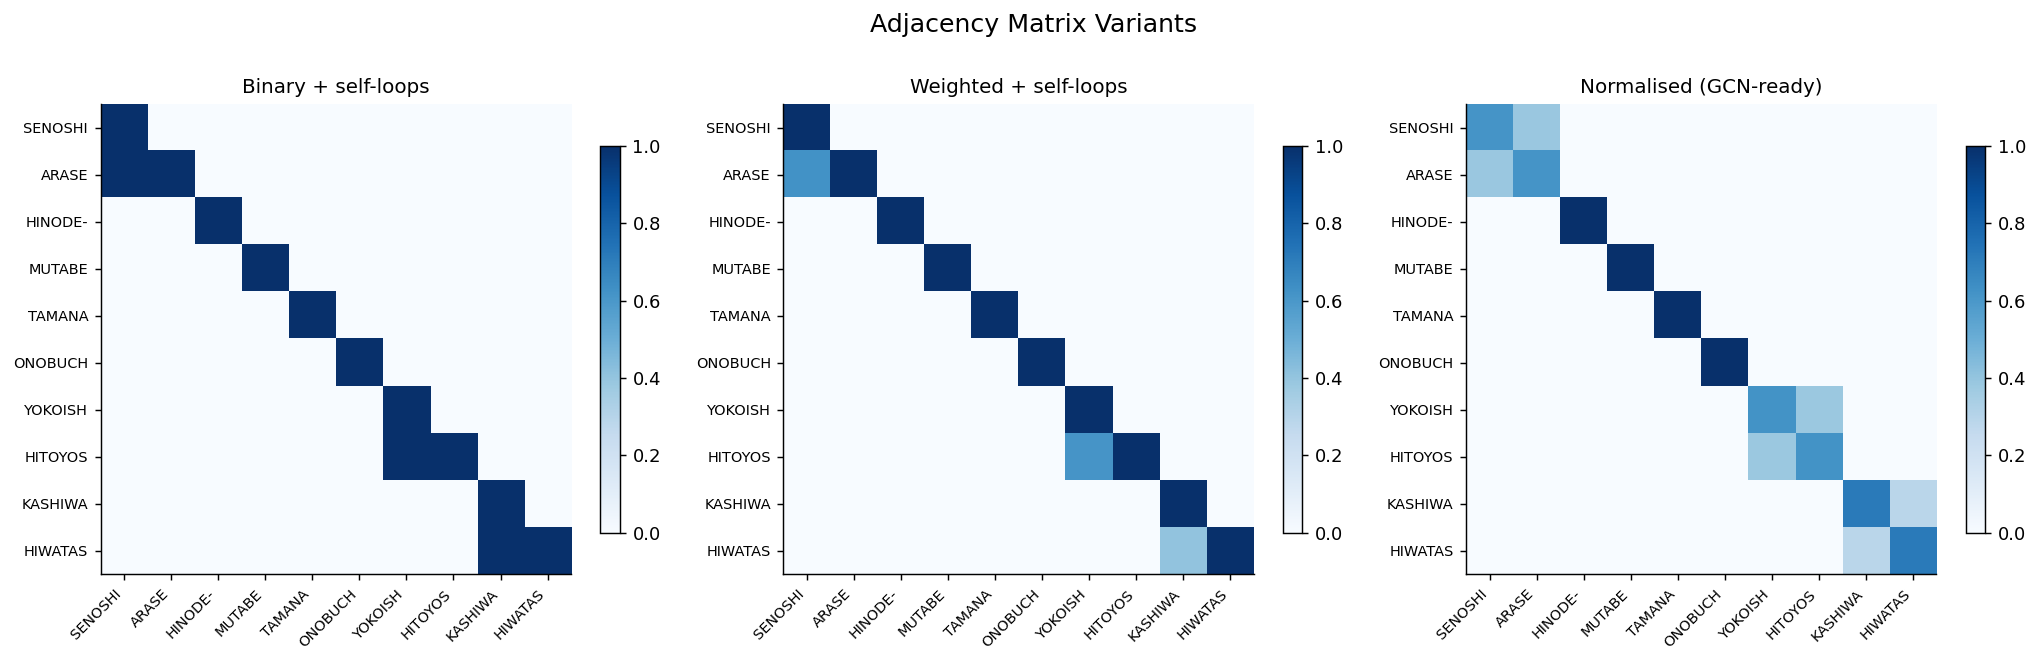

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

matrices = [
    (A_binary_sl,   "Binary + self-loops"),
    (A_weighted_sl, "Weighted + self-loops"),
    (A_norm,        "Normalised (GCN-ready)"),
]

for ax, (mat, title) in zip(axes, matrices):
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max())
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    short = [STATIONS[s]["name"][:7] for s in STATION_ORDER]
    ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle("Adjacency Matrix Variants", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
G = nx.DiGraph()

# Add nodes
for sid in STATION_ORDER:
    info = STATIONS[sid]
    G.add_node(
        sid,
        name=info["name"],
        river=info["river"],
        area=info["area"],
        lat=info["lat"],
        lon=info["lon"],
    )

# Add directed edges (upstream -> downstream)
for up_id, dn_id in TOPOLOGY.items():
    area_up = STATIONS[up_id]["area"]
    area_dn = STATIONS[dn_id]["area"]
    weight  = area_up / area_dn
    G.add_edge(up_id, dn_id, weight=round(weight, 3))

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print("\nEdge list:")
for u, v, d in G.edges(data=True):
    print(f"  {STATIONS[u]['name']:15s} -> {STATIONS[v]['name']:15s}  weight={d['weight']}")

Nodes : 10
Edges : 3

Edge list:
  ARASE           -> SENOSHITA        weight=0.623
  HITOYOSHI       -> YOKOISHI         weight=0.613
  HIWATASHI       -> KASHIWADA        weight=0.405


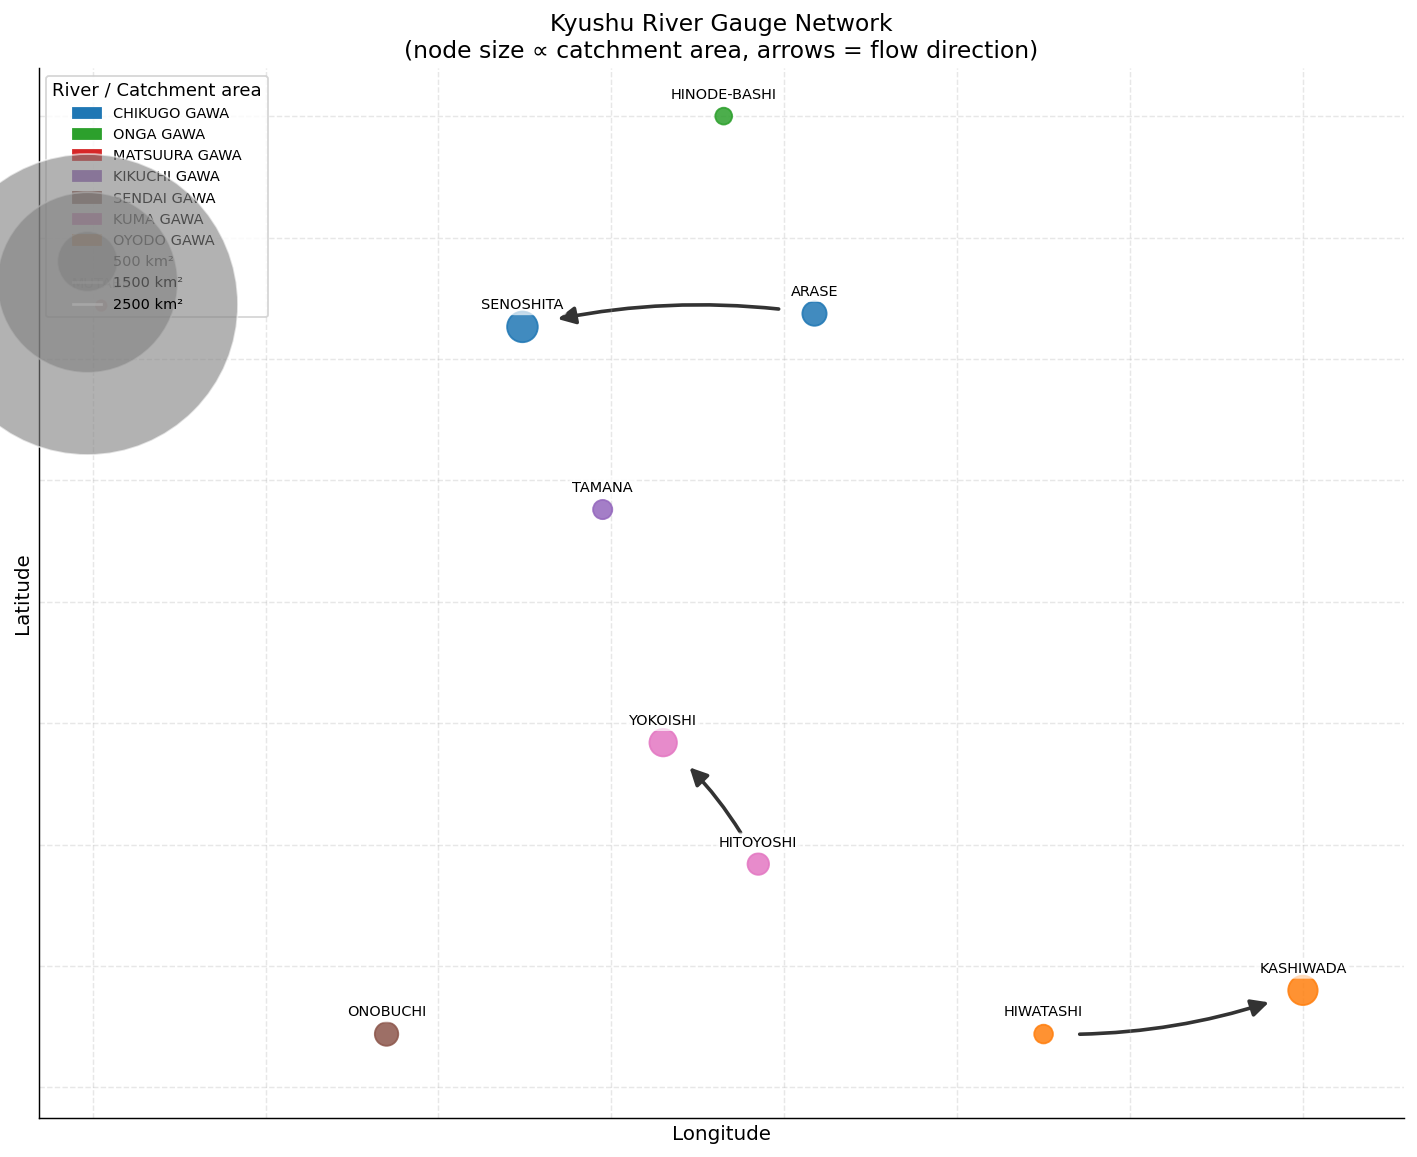

In [10]:
# Use lon/lat as node positions
pos = {sid: (STATIONS[sid]["lon"], STATIONS[sid]["lat"])
       for sid in STATION_ORDER}

# River -> color mapping
river_colors = {
    "CHIKUGO GAWA":  "#1f77b4",
    "ONGA GAWA":     "#2ca02c",
    "MATSUURA GAWA": "#d62728",
    "KIKUCHI GAWA":  "#9467bd",
    "SENDAI GAWA":   "#8c564b",
    "KUMA GAWA":     "#e377c2",
    "OYODO GAWA":    "#ff7f0e",
}

node_colors = [river_colors[STATIONS[s]["river"]] for s in G.nodes()]

# Node size proportional to catchment area
node_sizes = [STATIONS[s]["area"] / 8 for s in G.nodes()]

fig, ax = plt.subplots(figsize=(11, 9))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.85,
)

# Draw edges (directed arrows)
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color="#333333",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=20,
    width=2.0,
    connectionstyle="arc3,rad=0.1",
    min_source_margin=20,
    min_target_margin=20,
)

# Draw labels
offset = 0.03
for sid, (x, y) in pos.items():
    ax.text(x, y + offset, STATIONS[sid]["name"],
            fontsize=8, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0))

# Legend for rivers
legend_handles = [
    mpatches.Patch(color=c, label=r)
    for r, c in river_colors.items()
]
ax.legend(handles=legend_handles, loc="upper left",
          fontsize=9, title="River", title_fontsize=9)

# Size legend
for area, label in [(500, "500 km²"), (1500, "1500 km²"), (2500, "2500 km²")]:
    ax.scatter([], [], s=area/8, c="gray", alpha=0.6, label=label)
ax.legend(
    handles=legend_handles + [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markersize=s/15, label=l, alpha=0.6)
        for s, l in [(500,"500 km²"),(1500,"1500 km²"),(2500,"2500 km²")]
    ],
    loc="upper left", fontsize=8, title="River / Catchment area"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Kyushu River Gauge Network\n(node size ∝ catchment area, arrows = flow direction)",
             fontsize=13)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

In [11]:
print("=== Graph Statistics ===\n")
print(f"Nodes              : {G.number_of_nodes()}")
print(f"Directed edges     : {G.number_of_edges()}")
print(f"Isolated nodes     : {len(list(nx.isolates(G)))}")
print(f"Connected pairs    : {len(TOPOLOGY)}")

print("\n--- Per-node degree ---")
degree_df = pd.DataFrame({
    "station":    [STATIONS[s]["name"] for s in STATION_ORDER],
    "river":      [STATIONS[s]["river"] for s in STATION_ORDER],
    "in_degree":  [G.in_degree(s) for s in STATION_ORDER],
    "out_degree": [G.out_degree(s) for s in STATION_ORDER],
    "area_km2":   [STATIONS[s]["area"] for s in STATION_ORDER],
}).set_index("station")
print(degree_df.to_string())

print("\n--- Isolated stations (no topological pair in dataset) ---")
for s in nx.isolates(G):
    print(f"  {s}  {STATIONS[s]['name']:15s}  {STATIONS[s]['river']}")
print("\nNote: isolated stations still contribute as independent nodes in the GNN.")

=== Graph Statistics ===

Nodes              : 10
Directed edges     : 3
Isolated nodes     : 4
Connected pairs    : 3

--- Per-node degree ---
                      river  in_degree  out_degree  area_km2
station                                                     
SENOSHITA      CHIKUGO GAWA          1           0    2315.0
ARASE          CHIKUGO GAWA          0           1    1443.0
HINODE-BASHI      ONGA GAWA          0           0     695.0
MUTABE        MATSUURA GAWA          0           0     275.0
TAMANA         KIKUCHI GAWA          0           0     906.0
ONOBUCHI        SENDAI GAWA          0           0    1348.0
YOKOISHI          KUMA GAWA          1           0    1856.0
HITOYOSHI         KUMA GAWA          0           1    1137.0
KASHIWADA        OYODO GAWA          1           0    2126.0
HIWATASHI        OYODO GAWA          0           1     860.6

--- Isolated stations (no topological pair in dataset) ---
  2590200  HINODE-BASHI     ONGA GAWA
  2590210  MUTABE         